# Table 3 SCLC Results - SCLC MTL

Reviewer's request:
To facilitate the reviewer's examination and problem identification, the authors should provide reproducible code for calculating AUROC and c-index on GitHub, along with the raw data directly related to SCLC from Table 3, such as model outputs, corresponding patient survival times, and survival event information.



# 1. Preprocessing

## 1.1 RNA-Seq data

In [36]:
#imports 
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
%matplotlib inline

In [37]:
folder_path = 'Data/sclc_ucologne_2015/unused_data'
file_name = 'data_mrna_seq_fpkm.txt'
file_path = folder_path + '/' + file_name
# Load the RNAseq data from the csv file
data = pd.read_csv(file_path, sep='\t', index_col=0)

In [38]:
# First, we'll filter out genes with zero expression across all patient samples
df_filtered = data.loc[~(data.iloc[:, 2:].eq(0).all(axis=1))]

# Group by 'Hugo_Symbol', take the mean of each group, and reset the index
df_filtered = df_filtered.groupby('Hugo_Symbol').mean().reset_index()

# Calculate the sum of FPKM for each sample (each column starting from the third column)
sum_fpkm_per_sample = df_filtered.iloc[:, 2:].sum()

# Convert FPKM to TPM
# Divide each FPKM value by the sum of FPKM for that sample, then multiply by 10^6
df_tpm = df_filtered.copy()
df_tpm.iloc[:, 2:] = (df_filtered.iloc[:, 2:].div(sum_fpkm_per_sample)) * 10**6


# Drop the 'Entrez_Gene_Id' column
df_tpm = df_tpm.drop('Entrez_Gene_Id', axis=1)
#change name of column Hugo Symbol to gene gene_id
#df_tpm = df_tpm.rename(columns={'Hugo_Symbol': 'gene_id'})
df_tpm = df_tpm.rename(columns={'Hugo_Symbol': 'PATIENT_ID'})
# transpose the dataframe
df_tpm = df_tpm.T

# Make the gene_id row the column names
df_tpm.columns = df_tpm.iloc[0]
#delete the gene_id row
df_tpm = df_tpm.drop('PATIENT_ID')

#save the TPM data to a csv file
df_tpm.to_csv('Data/sclc_ucologne_2015/data_mrna_seq_tpm.csv', index=True)


### Select only the relevant genes from the gene file

In [39]:
BRCA= ['ESR1', 'EFTUD2', 'HSPA8', 'STAU1', 'SHMT2', 'ACTB', 'GSK3B', 'YWHAB', 'UBXN6', 'PRKRA', 'BTRC', 'DDX23', 'SSR1', 'TUBA1C', 'SNIP1', 'SRSF5', 'ERBB2', 'MKI67', 'PGR', 'PLAU']
LUAD= ['HNRNPU', 'STAU1', 'KDM1A', 'SERBP1', 'DHX9', 'EMC1', 'SSR1', 'PUM1', 'CLTC', 'PRKRA', 'KRR1', 'OCIAD1', 'CDC73', 'SLC2A1', 'HIF1A', 'PKM', 'CADM1', 'EPCAM', 'ALCAM', 'PTK7']
COAD= ['HNRNPL', 'HNRNPU', 'HNRNPA1', 'ZBTB2', 'SERBP1', 'RPL4', 'HNRNPK', 'HNRNPR', 'TFCP2', 'DHX9', 'RNF4', 'PUM1', 'ABCC1', 'CD44', 'ALCAM', 'ABCG2', 'ALDH1A1', 'ABCB1', 'EPCAM', 'PROM1']

# check the intersection of the genes in the BRCA, LUAD, COAD lists with the genes in the TPM dataframe
print("BRCA")
print(set(BRCA).intersection(df_tpm.columns), len(set(BRCA).intersection(df_tpm.columns)))
print("LUAD")
print(set(LUAD).intersection(df_tpm.columns),   len(set(LUAD).intersection(df_tpm.columns)))

print("COAD")
print(set(COAD).intersection(df_tpm.columns),   len(set(COAD).intersection(df_tpm.columns)))

#all three
print("all three")
print(set(BRCA).intersection(LUAD).intersection(COAD).intersection(df_tpm.columns))

selected_genes = list(set(BRCA).intersection(df_tpm.columns))

# Save smaller file, only with the selected genes

df_tpm.to_csv('Data/sclc_ucologne_2015/data_mrna_seq_tpm_small.csv', index=True)

BRCA
{'ESR1', 'SRSF5', 'STAU1', 'HSPA8', 'GSK3B', 'YWHAB', 'PLAU', 'ERBB2', 'SHMT2', 'SSR1', 'BTRC', 'PGR', 'SNIP1', 'MKI67', 'ACTB', 'DDX23', 'EFTUD2', 'UBXN6', 'PRKRA', 'TUBA1C'} 20
LUAD
{'KDM1A', 'SERBP1', 'SLC2A1', 'HNRNPU', 'PUM1', 'CDC73', 'OCIAD1', 'HIF1A', 'ALCAM', 'CADM1', 'DHX9', 'CLTC', 'PTK7', 'EPCAM', 'PRKRA', 'SSR1', 'STAU1', 'KRR1'} 18
COAD
{'HNRNPU', 'HNRNPR', 'TFCP2', 'EPCAM', 'HNRNPA1', 'CD44', 'RNF4', 'PUM1', 'ALCAM', 'DHX9', 'ALDH1A1', 'RPL4', 'SERBP1', 'HNRNPK', 'HNRNPL', 'ABCB1', 'ABCC1', 'ZBTB2', 'ABCG2', 'PROM1'} 20
all three
set()


## Process clinical data for SCLC

In [40]:
folder_path = 'Data/sclc_ucologne_2015'
file_name = 'data_clinical_patient_original.txt'
file_path = folder_path + '/' + file_name
# Load the clinical data from the csv file
data = pd.read_csv(file_path, sep='\t', index_col=0, header=0,skiprows=4, usecols=['PATIENT_ID','AGE', 'ETHNICITY', 'SEX', 'OS_STATUS', 'OS_MONTHS']  )

# the columns correspond to the patient IDs
# delete rows with no OS_STATUS
data = data[data['OS_STATUS'].notna()]


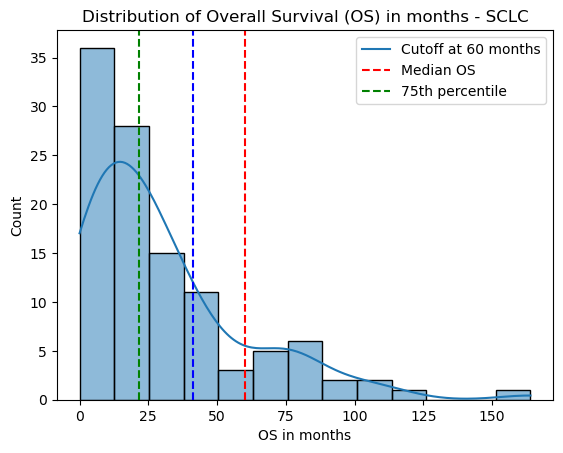

21.5
41.25


In [41]:
# plot distribution of OS_MONTHS
import seaborn as sns
import matplotlib.pyplot as plt


# Show cutoff at 60 months
# Show median OS

sns.histplot(data['OS_MONTHS'], kde=True)
plt.axvline(60, color='r', linestyle='--')
plt.axvline(data['OS_MONTHS'].median(), color='g', linestyle='--')
# legend
plt.legend({'Cutoff at 60 months': 60, 'Median OS': data['OS_MONTHS'].median(), '75th percentile': data['OS_MONTHS'].quantile(0.75)})
#show 75th percentile
plt.axvline(data['OS_MONTHS'].quantile(0.75), color='b', linestyle='--')

plt.title('Distribution of Overall Survival (OS) in months - SCLC')
plt.xlabel('OS in months')
plt.show()
print(data['OS_MONTHS'].median())
print(data['OS_MONTHS'].quantile(0.75))

In [42]:
#Relabeling to align with the nomenclature used in TCGA

data["race"] = data["ETHNICITY"] # TCGA only has the categories 'Hispanic or Latino', 
#'Not Hispanic or Latino', and 'Not reported', so we'll use race as a starting point
data['age_at_diagnosis'] = data['AGE']
os_years = data['OS_MONTHS'] / 12
data['year_of_diagnosis'] = 0
data['year_of_birth'] = 0
data['overall_survival'] = data['OS_MONTHS']
data['vital_status'] = data['OS_STATUS'] #Status (at time of last follow-up), found in the Supplementary Table 1
data['disease_specific_survival'] = data['OS_MONTHS']
data['primary_site'] = 'Bronchus and lung'

#replace "Asian" with "NOT HISPANIC OR LATINO, other with nan
data["ETHNICITY"].replace({"Asian": "not hispanic or latino"}, inplace=True)
# Replace all other values that are not "NOT HISPANIC OR LATINO" with NaN
data["ETHNICITY"] = data["ETHNICITY"].apply(lambda x: "not hispanic or latino" if x == "not hispanic or latino" else np.nan)
data["race"].replace({"Caucasian": "white", "Asian": "asian"}, inplace=True)
#change column names
data.rename(columns = {'PATIENT_ID':'patient_id', 'SEX': 'gender', 'ETHNICITY':'ethnicity' }, inplace = True)
#gender to lowercase
data['gender'] = data['gender'].str.lower() 
#drop AGE, OS_STATUS, OS_MONTHS
data.drop(columns = ['AGE', 'OS_STATUS', 'OS_MONTHS'], inplace = True)
#replace vital status labels with the nomenclature 1:DECEASED 0:LIVING
data["vital_status"].replace({"1:DECEASED": 1, "0:LIVING": 0}, inplace=True)

#Use the following categories:
#0: Not Known
#1: 'NOT HISPANIC OR LATINO'
#data.ethnicity.replace({"NOT HISPANIC OR LATINO": 1}, inplace=True)
#data.ethnicity.fillna(0, inplace=True)

#data.race.replace({"WHITE": 1, "ASIAN": 2}, inplace=True)
#data.race.fillna(0, inplace=True)
#drop rows with null overall_survival
data.dropna(subset=['overall_survival'], inplace=True)

data['survival_time'] = data['overall_survival']



In [43]:
# Display data to check for any anomalies
data

,gender,ethnicity,race,age_at_diagnosis,year_of_diagnosis,year_of_birth,overall_survival,vital_status,disease_specific_survival,primary_site,survival_time
PATIENT_ID,,,,,,,,,,,
sclc_ucologne_2015_S00022,male,NaN,NaN,47.0,0,0,38.0,1,38.0,Bronchus and lung,38.0
sclc_ucologne_2015_S00035,female,NaN,NaN,65.0,0,0,12.0,1,12.0,Bronchus and lung,12.0
sclc_ucologne_2015_S00050,male,NaN,NaN,47.0,0,0,42.0,1,42.0,Bronchus and lung,42.0
sclc_ucologne_2015_S00213,male,NaN,NaN,65.0,0,0,13.0,1,13.0,Bronchus and lung,13.0
sclc_ucologne_2015_S00356,female,NaN,NaN,54.0,0,0,33.0,1,33.0,Bronchus and lung,33.0
...,...,...,...,...,...,...,...,...,...,...,...
sclc_ucologne_2015_S02400,male,not hispanic or latino,asian,44.0,0,0,0.0,1,0.0,Bronchus and lung,0.0
sclc_ucologne_2015_S02401,male,not hispanic or latino,asian,72.0,0,0,1.0,0,1.0,Bronchus and lung,1.0
sclc_ucologne_2015_S02402,male,not hispanic or latino,asian,57.0,0,0,47.0,0,47.0,Bronchus and lung,47.0


### Censoring

In [44]:
# Print just the vital status and overall survival columns
# Specifically, we want to check if there are any patients who are alive but have an overall survival of less than 60 days
print("Number of rows before removing patients with overall survival less than 60 days and marked as alive:", len(data))
print("Checking for living patients with overall survival less than 60 days:")
count_removed = 0
for index, row in data.iterrows():
    if row['vital_status'] == 0:
        if row['overall_survival'] <= 60:
            #print(row['overall_survival'], row['vital_status'])
            # remove from data
            data.drop(index, inplace=True)
            count_removed += 1

print("Number of right-censored patients removed:", count_removed)


print("Number of rows after removing patients with overall survival less than 60 days and alive:", len(data))

# Check opposite case: if a patient is marked as deceased but has overall survival greater than 60 days
# Change to vital status 0
print("Checking for deceased patients with overall survival greater than 60 days:")
for index, row in data.iterrows():
    if row['vital_status'] == 1:
        if row['overall_survival'] > 60:
            #print(row['overall_survival'], row['vital_status'])
            # replace the vital status with 0
            data.loc[index, 'vital_status'] = 0
    
#save the clinical data to a csv file
data[['vital_status', 'overall_survival']].to_csv('check_vitalstatus.csv', index=True)

Number of rows before removing patients with overall survival less than 60 days and marked as alive: 110
Checking for living patients with overall survival less than 60 days:
Number of right-censored patients removed: 22
Number of rows after removing patients with overall survival less than 60 days and alive: 88
Checking for deceased patients with overall survival greater than 60 days:


In [45]:
# months_threshold = 60
# data['disease_specific_survival'] = (data['disease_specific_survival'] < months_threshold).astype(int)
# data['overall_survival'] = (data['overall_survival'] < months_threshold).astype(int)

In [46]:
data.head()

,gender,ethnicity,race,age_at_diagnosis,year_of_diagnosis,year_of_birth,overall_survival,vital_status,disease_specific_survival,primary_site,survival_time
PATIENT_ID,,,,,,,,,,,
sclc_ucologne_2015_S00022,male,NaN,NaN,47.0,0,0,38.0,1,38.0,Bronchus and lung,38.0
sclc_ucologne_2015_S00035,female,NaN,NaN,65.0,0,0,12.0,1,12.0,Bronchus and lung,12.0
sclc_ucologne_2015_S00050,male,NaN,NaN,47.0,0,0,42.0,1,42.0,Bronchus and lung,42.0
sclc_ucologne_2015_S00213,male,NaN,NaN,65.0,0,0,13.0,1,13.0,Bronchus and lung,13.0
sclc_ucologne_2015_S00356,female,NaN,NaN,54.0,0,0,33.0,1,33.0,Bronchus and lung,33.0


In [48]:
#save to csv
data.to_csv(folder_path + '/data_clinical_patient.csv', sep=',')

# Model 


In [19]:
import argparse
from datetime import datetime
from pathlib import Path
from warnings import filterwarnings

import lightning.pytorch as pl
import pandas as pd
import torch
import yaml
from tqdm import tqdm

from dataset import TCGA_Program_Dataset
from datasets_manager import TCGA_Balanced_Datasets_Manager, TCGA_Datasets_Manager
from lit_models import LitFullModel
from model import Classifier, Feature_Extractor, Graph_And_Clinical_Feature_Extractor, Task_Classifier
from utils import config_add_subdict_key, get_logger, override_n_genes, set_random_seed, setup_logging
from external_lightningdatamodule import ExternalDataModule

filterwarnings('ignore', r'.*Skipping val loop.*')
# Suppress specific warning about shuffling in dataloaders
filterwarnings(
    action='ignore',
    message=".*shuffling enabled.*",
    category=UserWarning,  # Adjust the category if necessary
    module='pytorch_lightning'  # Adjust if the warning is from a different module
)  


SEED = 1126
set_random_seed(SEED)


In [20]:

def create_models_and_optimizers(config: dict):
    models: dict[str, torch.nn.Module] = {}
    optimizers: dict[str, torch.optim.Optimizer] = {}

    # Setup models. Do not use getattr() for better IDE support.
    for model_name, kargs in config['models'].items():
        if model_name == 'Graph_And_Clinical_Feature_Extractor':
            models['feat_ext'] = Graph_And_Clinical_Feature_Extractor(**kargs)
        elif model_name == 'Feature_Extractor':
            models['feat_ext'] = Feature_Extractor(**kargs)
        elif model_name == 'Task_Classifier':
            models['clf'] = Task_Classifier(**kargs)
        elif model_name == 'Classifier':
            models['clf'] = Classifier(**kargs)
        else:
            raise ValueError(f'Unknown model type: {model_name}')

    # Setup optimizers. If the key is 'all', the optimizer will be applied to all models.
    for key, optim_dict in config['optimizers'].items():
        opt_name = next(iter(optim_dict))
        if key == 'all':
            params = [param for model in models.values() for param in model.parameters()]
            optimizers[key] = getattr(torch.optim, opt_name)(params, **optim_dict[opt_name])
        else:
            optimizers[key] = getattr(torch.optim, opt_name)(models[key].parameters(), **optim_dict[opt_name])

    # Add models' structure to config for logging. TODO: Prettify.
    for model_name, torch_model in models.items():
        config[f'model.{model_name}'] = str(torch_model)
    return models, optimizers



In [21]:
def cross_validation(manager, config, log_path, external_testing_dataloader):
    for key, values in manager['TCGA_BLC']['dataloaders'].items():
        if isinstance(key, int) and config['cross_validation']:
            models, optimizers = create_models_and_optimizers(config)
            lit_model = LitFullModel(models, optimizers, config)
            trainer = pl.Trainer(                                               # Create sub-folders for each fold.
                default_root_dir=log_path,
                max_epochs=config['max_epochs'],
                log_every_n_steps=1,
                enable_model_summary=False,
                enable_checkpointing=False,
                
            )
            
            trainer.fit(lit_model, train_dataloaders=values['train'])
            
        
        elif key == 'train':
            train = values
        elif key == 'test':
            test = external_testing_dataloader #values
    return train, test

In [22]:


def main(config_file):
    # Select a config file.

 
    with open(config_file, 'r') as f:
        config = yaml.load(f, Loader=yaml.FullLoader)
    override_n_genes(config)                        # For multi-task graph models.
    config_name = Path(config_file).stem

    # Setup logging.
    log_path = f'Logs/{config_name}/{datetime.now():%Y-%m-%dT%H:%M:%S}/'
    setup_logging(log_path)
    
    logger = get_logger(config_name)
    logger.info(f'Using Random Seed {SEED} for this experiment')
    
    get_logger('lightning.pytorch.accelerators.cuda', log_level='WARNING')      # Disable cuda logging.
    filterwarnings('ignore', r'.*Skipping val loop.*')                          # Disable val loop warning.
    filterwarnings('ignore', r".*Your `test_dataloader`'s sampler has shuffling enabled*")    # Disable val shuffle warning.


    #add the external data
    external_testing_data = ExternalDataModule(**config['external_datasets']) 

    external_testing_data.setup()

    external_testing_dataloader = external_testing_data.test_dataloader()

     # Create dataset manager for training data.
    data = {'TCGA_BLC': TCGA_Program_Dataset(**config['datasets'])}
    
    
    
    if 'TCGA_Balanced_Datasets_Manager' == config['datasets_manager']['type']:
        manager = TCGA_Balanced_Datasets_Manager(datasets=data, config=config_add_subdict_key(config))
    else:
        manager = TCGA_Datasets_Manager(datasets=data, config=config_add_subdict_key(config))

    
    for key, values in manager['TCGA_BLC']['dataloaders'].items():
        if isinstance(key, int) and config['cross_validation']:
            models, optimizers = create_models_and_optimizers(config)
            lit_model = LitFullModel(models, optimizers, config)
            trainer = pl.Trainer(                                               # Create sub-folders for each fold.
                default_root_dir=log_path,
                max_epochs=config['max_epochs'],
                log_every_n_steps=1,
                enable_model_summary=False,
                enable_checkpointing=False,
                
            )
            
            trainer.fit(lit_model, train_dataloaders=values['train'])
            #trainer.test(lit_model, dataloaders=test, verbose=True)          
               
            
        elif key == 'train':
            train = values
        elif key == 'test':
             test = external_testing_dataloader
    # Train the final model from scratch with all the training data.
    models, optimizers = create_models_and_optimizers(config)
    lit_model = LitFullModel(models, optimizers, config)
    trainer = pl.Trainer(
        default_root_dir=log_path,
        max_epochs=config['max_epochs'],
        enable_progress_bar=False,
        log_every_n_steps=1,
        logger=False,
    )
    trainer.fit(lit_model, train_dataloaders=train)

    # Test the final model.
    bootstrap_results = []
    for _ in tqdm(range(config['bootstrap_repeats']), desc='Bootstrapping'):
        
        bootstrap_results.append(trainer.test(lit_model, dataloaders=test, verbose=False)[0]) 
        

    bootstrap_results = pd.DataFrame.from_records(bootstrap_results)
    for key, value in bootstrap_results.describe().loc[['mean', 'std']].to_dict().items():
        logger.info(f'| {key.ljust(10).upper()} | {value["mean"]:.5f} ± {value["std"]:.5f} |')

    del bootstrap_results
        
    return trainer, train, test, models, optimizers, config, lit_model, logger



# Model evaluation
The results correspond to the "MTL - SCLC" row of Table 3.

In [23]:

 # Run the main function.
trainer, train, test, models, optimizers, config, lit_model, logger = main("config/light/MTL_train_SCLC_test.yaml")



[INFO]	Using Random Seed 1126 for this experiment


[INFO]	External DS - Total 88 patients
[INFO]	Normalize clinical numerical data using all samples
[INFO]	External DS - Total 88 samples after removing missing values


KeyError: "None of [Index(['gender', 'race', 'ethnicity'], dtype='object')] are in the [columns]"

# Check outputs

In [ ]:

from utils.runner.metric import youden_j, c_index
from sklearn.metrics import roc_auc_score, roc_curve

# Load last trained model and check for the outputs
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
latest_datetime = max(os.listdir('Logs/MTL_train_SCLC_test/'))
weights_path = f'Logs/MTL_train_SCLC_test/{latest_datetime}/checkpoints/epoch=49-step=1300.ckpt'
lit_model = LitFullModel.load_from_checkpoint(weights_path,  models=models, optimizers=optimizers, config=config)
# show the model output
lit_model.to(device)
lit_model.eval()
batch_id = 0
for batch1, batch2 in test:    
    genomic, clinical, index, project_id = batch1
    overall_survival, survival_time, vital_status = batch2
    #batch is a tuple with this structure ((genomic, clinical, index, project_id), (overall_survival, survival_time, vital_status))
    batch1 = (genomic.to(device), clinical.to(device), index.to(device), project_id.to(device))
    batch2 = (overall_survival.to(device), survival_time.to(device), vital_status.to(device))
    batch = (batch1, batch2)
    output = lit_model.predict_step(batch, batch_id)
    labels = overall_survival
    #opposite of output is the probability of survival
    psurvival = output #1 - output    
    after_sigmoid = torch.functional.F.sigmoid(torch.tensor(output).to(device))  
    # transform to binary
    #determine threshold
    fpr, tpr, thresholds = roc_curve(labels, output)
    print('Thresholds:', thresholds)
    thrs =  0.45744
    print('Optimal Threshold:', thrs)
    print('After Sigmoid', after_sigmoid)
    output_binary = (after_sigmoid.cpu().detach() < thrs).float()
    print('Binary Output', output_binary)
    print('Labels', overall_survival)
    print('Survival_Time', survival_time)
    print('Vital_Status', vital_status)

    # Calculate C-index
    c_index = c_index(torch.from_numpy(output_binary.cpu().numpy()), survival_time, vital_status)
    print('C-index:', c_index)

    #AUROC

    print('AUROC:', roc_auc_score(overall_survival.cpu().numpy(), output_binary.to('cpu').detach().numpy()))
    

    for i in torch.unique(project_id):
        print(f'Project ID: {i}')
        print(f'Number of samples: {torch.sum(project_id == i)}')
        print(f'Number of samples with vital status 1: {torch.sum((project_id == i) & (vital_status == 1))}')
        print(f'Number of samples with vital status 0: {torch.sum((project_id == i) & (vital_status == 0))}')
        print(f'Number of samples with predicted OS 1: {torch.sum((project_id == i) & (output_binary == 1))}')
        print(f'Number of samples with predicted OS 0: {torch.sum((project_id == i) & (output_binary == 0))}')
    
    # Save csv with columns: index, output, output_binary, labels,  vital_status, survival_time
    df = pd.DataFrame({'output': output, 'output_binary': output_binary.cpu(), 'labels': labels.cpu(), 'vital_status': vital_status.cpu(), 'survival_time': survival_time.cpu()})
    df.to_csv(f'output.csv', index=True)







Thresholds: [-2.2913272 -3.2913272 -3.4579062 -3.602354  -3.7345788 -3.8582802
 -4.049616  -4.0814023 -4.087405  -4.1239705 -4.12457   -4.1319013
 -4.1577635 -4.1749525 -4.181863  -4.2016854 -4.224572  -4.2283754
 -4.2442074 -4.282344  -4.311477  -4.3156214 -4.393559  -4.447122
 -4.456211  -4.463292  -4.494787  -4.4959307 -4.498499  -4.4997416
 -4.523244  -4.552884  -4.6270595 -4.6555758 -4.7097425 -4.752748
 -4.760202  -4.8095746]
Optimal Threshold: 0.45744
After Sigmoid tensor([0.0114, 0.0147, 0.0147, 0.0115, 0.0081, 0.0359, 0.0100, 0.0085, 0.0110,
        0.0116, 0.0151, 0.0110, 0.0151, 0.0115, 0.0122, 0.0144, 0.0108, 0.0110,
        0.0305, 0.0158, 0.0132, 0.0116, 0.0265, 0.0110, 0.0158, 0.0159, 0.0132,
        0.0141, 0.0233, 0.0118, 0.0144, 0.0096, 0.0118, 0.0159, 0.0154, 0.0085,
        0.0136, 0.0086, 0.0122, 0.0097, 0.0107, 0.0136, 0.0359, 0.0110, 0.0100,
        0.0157, 0.0103, 0.0165, 0.0159, 0.0265, 0.0094, 0.0316, 0.0094, 0.0085,
        0.0245, 0.0110, 0.0159, 0.0089, 0.0